# Кейс 6: метрические методы регрессии — интерактивный демо

Ноутбук показывает работу всех трёх моделей (NW fixed, NW variable, LOWESS) на синтетике и реальных данных. Каждая ячейка самостоятельна и не зависит от состояния предыдущих, кроме первых двух (импорты).

In [1]:
import sys, pathlib
ROOT = pathlib.Path().resolve().parents[1] if pathlib.Path().resolve().name == 'case_6' else pathlib.Path().resolve()
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import matplotlib.pyplot as plt

from case_6.data import (
    make_sinusoidal_dataset, make_sinusoidal_split,
    inject_outliers, train_test_split, load_real_datasets,
)
from case_6.distance import pairwise_euclidean
from case_6.kernels import KERNELS
from case_6.nadaraya_watson import nw_predict_fixed, nw_predict_variable
from case_6.lowess import lowess_fit_predict, lowess_predict_query
from case_6.selection import (
    loo_score_fixed, loo_score_variable, loo_score_lowess,
    select_fixed_window, select_variable_window, select_lowess,
)
from case_6.metrics import mae, rmse, r2

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Ядра

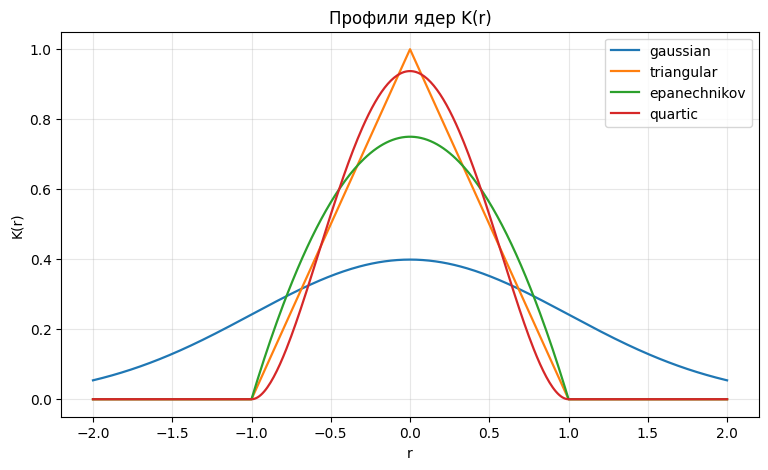

In [2]:
r = np.linspace(-2.0, 2.0, 401)
plt.figure()
for name, k in KERNELS.items():
    plt.plot(r, k(r), linewidth=1.6, label=name)
plt.title('Профили ядер K(r)')
plt.xlabel('r'); plt.ylabel('K(r)'); plt.legend()
plt.show()

## 2. NW c фиксированным окном — иллюстрация роли h

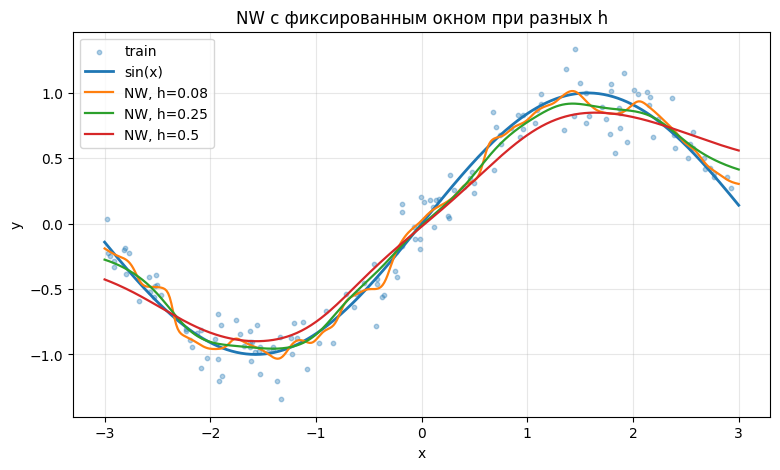

In [3]:
train, test = make_sinusoidal_split(n_samples=200, noise_std=0.13, train_outlier_fraction=0.0, seed=123)
x_grid = np.linspace(-3, 3, 400)[:, None]

plt.figure()
plt.scatter(train.x[:,0], train.y, s=10, alpha=0.35, label='train')
plt.plot(x_grid[:,0], np.sin(x_grid[:,0]), label='sin(x)', linewidth=2)
for h in [0.08, 0.25, 0.5]:
    pred = nw_predict_fixed(train.x, train.y, x_grid, h=h, kernel_name='gaussian')
    plt.plot(x_grid[:,0], pred, label=f'NW, h={h}', linewidth=1.6)
plt.legend(); plt.title('NW с фиксированным окном при разных h')
plt.xlabel('x'); plt.ylabel('y'); plt.show()

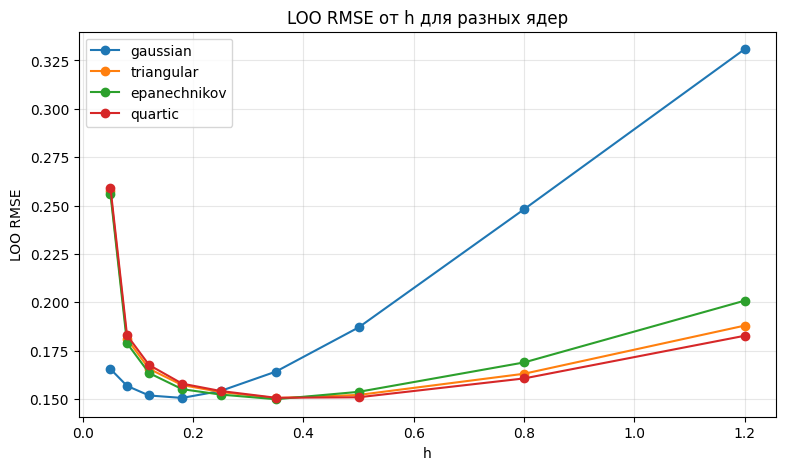

gaussian      best h=0.18, LOO=0.1506
triangular    best h=0.35, LOO=0.1505
epanechnikov  best h=0.35, LOO=0.1500
quartic       best h=0.35, LOO=0.1507


In [4]:
hs = [0.05, 0.08, 0.12, 0.18, 0.25, 0.35, 0.5, 0.8, 1.2]
loo_curves = {}
for kern in KERNELS:
    loo_curves[kern] = [loo_score_fixed(train.x, train.y, h=h, kernel_name=kern) for h in hs]

plt.figure()
for kern, vals in loo_curves.items():
    plt.plot(hs, vals, marker='o', label=kern)
plt.xlabel('h'); plt.ylabel('LOO RMSE'); plt.title('LOO RMSE от h для разных ядер'); plt.legend()
plt.show()

for kern, vals in loo_curves.items():
    i = int(np.argmin(vals))
    print(f'{kern:13s} best h={hs[i]:.2f}, LOO={vals[i]:.4f}')

## 3. Переменное окно — выбор k

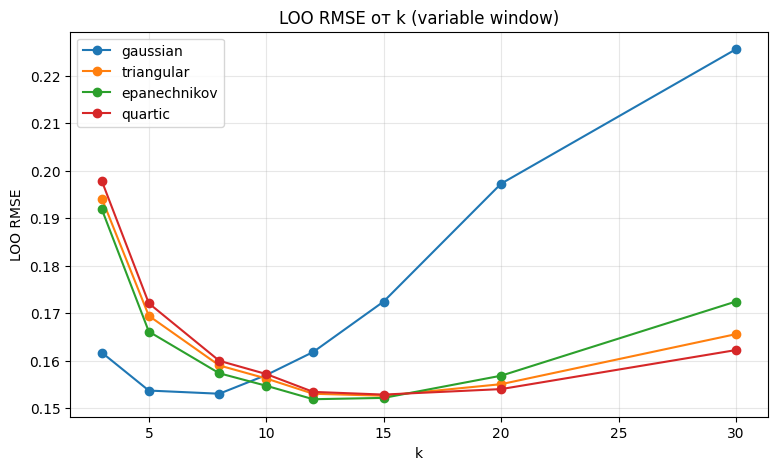

In [5]:
ks = [3, 5, 8, 10, 12, 15, 20, 30]
loo_curves_k = {kern: [loo_score_variable(train.x, train.y, k=k, kernel_name=kern) for k in ks] for kern in KERNELS}

plt.figure()
for kern, vals in loo_curves_k.items():
    plt.plot(ks, vals, marker='o', label=kern)
plt.xlabel('k'); plt.ylabel('LOO RMSE'); plt.title('LOO RMSE от k (variable window)'); plt.legend()
plt.show()

## 4. LOWESS: эффект перевзвешивания

Принудительно добавим в обучающую часть 20% выбросов.

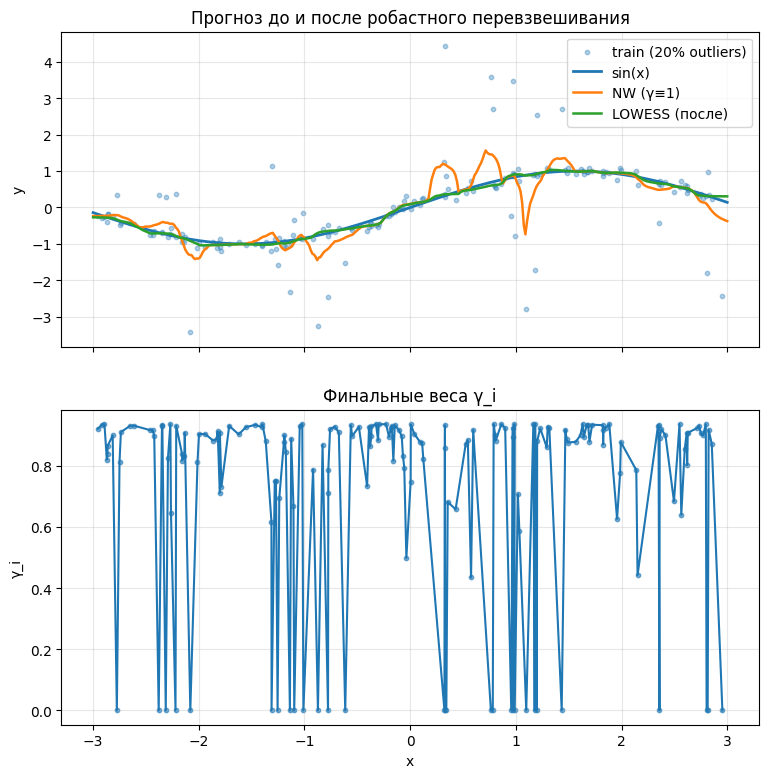

Test RMSE: NW=0.3682, LOWESS=0.1245
Test MAE:  NW=0.2411, LOWESS=0.0950
Test R²:   NW=0.7788, LOWESS=0.9747


In [6]:
train_o, test_o = make_sinusoidal_split(n_samples=240, noise_std=0.1, train_outlier_fraction=0.2, outlier_scale=2.0, seed=42)
k_best = 10; kern_best = 'quartic'

pred_nw_grid = nw_predict_variable(train_o.x, train_o.y, x_grid, k=k_best, kernel_name=kern_best)
_, gamma = lowess_fit_predict(train_o.x, train_o.y, k=k_best, kernel_name=kern_best)
pred_lo_grid = lowess_predict_query(train_o.x, train_o.y, gamma, x_grid, k=k_best, kernel_name=kern_best)

fig, ax = plt.subplots(2, 1, figsize=(9, 9), sharex=True)
ax[0].scatter(train_o.x[:,0], train_o.y, s=10, alpha=0.35, label='train (20% outliers)')
ax[0].plot(x_grid[:,0], np.sin(x_grid[:,0]), label='sin(x)', linewidth=2)
ax[0].plot(x_grid[:,0], pred_nw_grid, label='NW (γ≡1)', linewidth=1.8)
ax[0].plot(x_grid[:,0], pred_lo_grid, label='LOWESS (после)', linewidth=1.8)
ax[0].set_ylabel('y'); ax[0].legend(); ax[0].set_title('Прогноз до и после робастного перевзвешивания')

order = np.argsort(train_o.x[:,0])
ax[1].plot(train_o.x[order,0], gamma[order], linewidth=1.5)
ax[1].scatter(train_o.x[order,0], gamma[order], s=10, alpha=0.6)
ax[1].set_xlabel('x'); ax[1].set_ylabel('γ_i'); ax[1].set_title('Финальные веса γ_i')
plt.show()

pred_nw_test = nw_predict_variable(train_o.x, train_o.y, test_o.x, k=k_best, kernel_name=kern_best)
pred_lo_test = lowess_predict_query(train_o.x, train_o.y, gamma, test_o.x, k=k_best, kernel_name=kern_best)
print(f'Test RMSE: NW={rmse(test_o.y, pred_nw_test):.4f}, LOWESS={rmse(test_o.y, pred_lo_test):.4f}')
print(f'Test MAE:  NW={mae(test_o.y, pred_nw_test):.4f}, LOWESS={mae(test_o.y, pred_lo_test):.4f}')
print(f'Test R²:   NW={r2(test_o.y, pred_nw_test):.4f}, LOWESS={r2(test_o.y, pred_lo_test):.4f}')

## 5. Сканирование по уровню выбросов: когда LOWESS начинает выигрывать

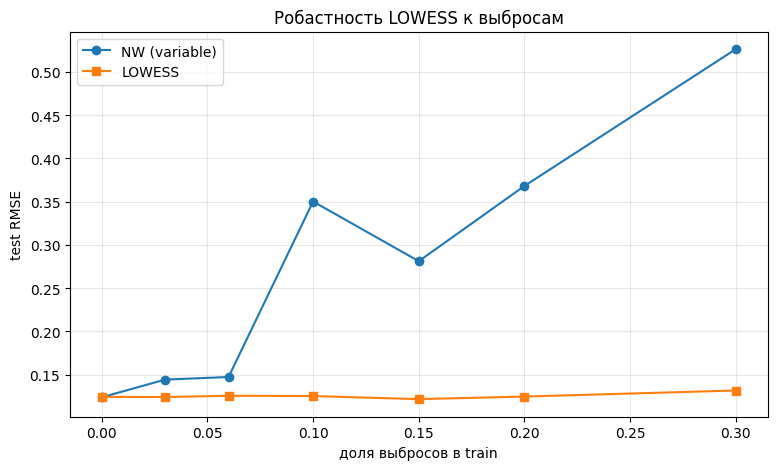

  frac         NW     LOWESS
  0.00     0.1236     0.1242
  0.03     0.1441     0.1239
  0.06     0.1471     0.1254
  0.10     0.3502     0.1251
  0.15     0.2811     0.1215
  0.20     0.3682     0.1245
  0.30     0.5265     0.1315


In [7]:
fracs = [0.0, 0.03, 0.06, 0.1, 0.15, 0.2, 0.3]
rmse_nw, rmse_lo = [], []
for frac in fracs:
    tr, te = make_sinusoidal_split(n_samples=240, noise_std=0.1, train_outlier_fraction=frac, seed=42)
    pred_nw = nw_predict_variable(tr.x, tr.y, te.x, k=10, kernel_name='quartic')
    _, g = lowess_fit_predict(tr.x, tr.y, k=10, kernel_name='quartic')
    pred_lo = lowess_predict_query(tr.x, tr.y, g, te.x, k=10, kernel_name='quartic')
    rmse_nw.append(rmse(te.y, pred_nw)); rmse_lo.append(rmse(te.y, pred_lo))

plt.figure()
plt.plot(fracs, rmse_nw, marker='o', label='NW (variable)')
plt.plot(fracs, rmse_lo, marker='s', label='LOWESS')
plt.xlabel('доля выбросов в train'); plt.ylabel('test RMSE')
plt.title('Робастность LOWESS к выбросам'); plt.legend()
plt.show()

print(f"{'frac':>6} {'NW':>10} {'LOWESS':>10}")
for f, n, l in zip(fracs, rmse_nw, rmse_lo):
    print(f'{f:>6.2f} {n:>10.4f} {l:>10.4f}')

## 6. Реальные данные: Diabetes и California Housing

In [8]:
datasets = load_real_datasets(seed=42)

for name, (tr, te) in datasets.items():
    diam = float(np.median(np.linalg.norm(tr.x, axis=1)))
    hs = [0.25*diam, 0.5*diam, diam, 1.5*diam, 2.0*diam]
    ks = sorted({5, 10, 20, 40, min(80, tr.x.shape[0]//4)})
    kerns = ['gaussian', 'epanechnikov', 'quartic']

    best_h = select_fixed_window(tr.x, tr.y, hs=hs, kernels=kerns)
    best_k = select_variable_window(tr.x, tr.y, ks=ks, kernels=kerns)
    pred_f = nw_predict_fixed(tr.x, tr.y, te.x, h=best_h.param_value, kernel_name=best_h.kernel_name)
    pred_v = nw_predict_variable(tr.x, tr.y, te.x, k=int(best_k.param_value), kernel_name=best_k.kernel_name)

    print(f'=== {name} ===')
    print(f'  fixed   : {best_h.kernel_name:13s} h={best_h.param_value:.3f}  LOO={best_h.score_rmse:.3f}  test RMSE={rmse(te.y, pred_f):.3f} MAE={mae(te.y, pred_f):.3f} R²={r2(te.y, pred_f):.3f}')
    print(f'  variable: {best_k.kernel_name:13s} k={int(best_k.param_value):<3} LOO={best_k.score_rmse:.3f}  test RMSE={rmse(te.y, pred_v):.3f} MAE={mae(te.y, pred_v):.3f} R²={r2(te.y, pred_v):.3f}')

=== diabetes ===
  fixed   : epanechnikov  h=2.928  LOO=58.888  test RMSE=57.984 MAE=47.582 R²=0.458
  variable: quartic       k=40  LOO=57.622  test RMSE=57.610 MAE=46.553 R²=0.465


=== california_housing ===
  fixed   : gaussian      h=0.542  LOO=0.691  test RMSE=0.783 MAE=0.562 R²=0.590
  variable: quartic       k=20  LOO=0.649  test RMSE=0.725 MAE=0.500 R²=0.648


## 7. Что важнее — ядро или ширина окна?

Средний std LOO при фиксированном h, меняя ядро: 0.0111
Средний std LOO при фиксированном ядре, меняя h: 0.0157
Отношение влияний (h/ядро): 1.4×


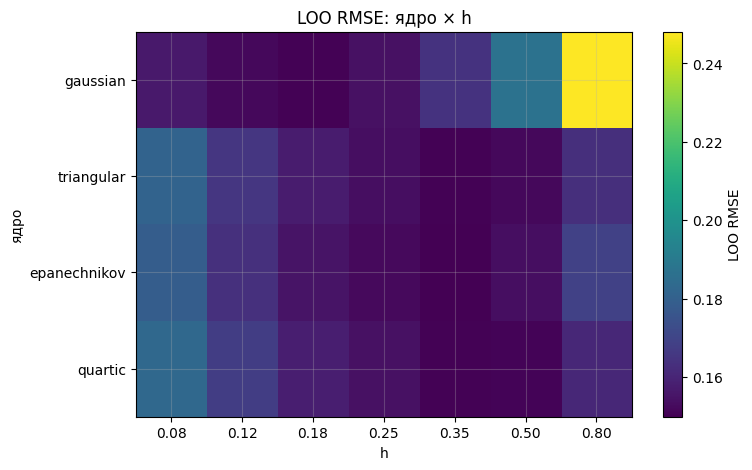

In [9]:
# Для каждой пары (kernel, h) считаем LOO. Разброс по h vs по ядру на одинаковом h.
hs = [0.08, 0.12, 0.18, 0.25, 0.35, 0.5, 0.8]
grid = np.zeros((len(KERNELS), len(hs)))
for i, kern in enumerate(KERNELS):
    for j, h in enumerate(hs):
        grid[i, j] = loo_score_fixed(train.x, train.y, h=h, kernel_name=kern)

spread_over_kernels = grid.std(axis=0).mean()
spread_over_h = grid.std(axis=1).mean()
print(f'Средний std LOO при фиксированном h, меняя ядро: {spread_over_kernels:.4f}')
print(f'Средний std LOO при фиксированном ядре, меняя h: {spread_over_h:.4f}')
print(f'Отношение влияний (h/ядро): {spread_over_h / spread_over_kernels:.1f}×')

import matplotlib
plt.figure(figsize=(8, 5))
im = plt.imshow(grid, aspect='auto', cmap='viridis')
plt.colorbar(im, label='LOO RMSE')
plt.yticks(range(len(KERNELS)), list(KERNELS.keys()))
plt.xticks(range(len(hs)), [f'{h:.2f}' for h in hs])
plt.xlabel('h'); plt.ylabel('ядро'); plt.title('LOO RMSE: ядро × h')
plt.show()

## Резюме

1. Все три модели реализованы с нуля и проходят корректность (см. `tests/case_6/`).
2. Подбор $h$, $k$, ядра — по LOO.
3. Выбор $h$ влияет на качество существенно сильнее выбора ядра.
4. Переменное окно даёт ощутимый выигрыш на реальных данных с неоднородной плотностью.
5. LOWESS строго лучше NW при загрязнении $\ge 6\%$; при чистых данных небольшая «налогообложение» эффективности.